In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

### Load processed data 

In [84]:
X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
X_test_scaled = np.load("../data/processed/X_test_scaled.npy")
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

### Find best K-value

In [85]:
K_values = range(1,61)
accuracies = []

for k in K_values:
    # instantiate the model with k 
    knn = KNeighborsClassifier(n_neighbors=k,weights='distance')
    scores = cross_val_score(knn,X_train_scaled,y_train,cv=5)
    accuracies.append(scores.mean())
# print top 5 k values and their accuracies
top_5 = sorted(zip(K_values,accuracies),key=lambda x:x[1],reverse =True)[:5]
for k,acc in top_5:
    print(f" K:{k}:{acc:.4f}")
best_k_idx = np.argmax(accuracies)
best_k = K_values[best_k_idx]
print(f'{best_k} with accuracy:{max(accuracies):.4f}')



 K:36:0.8448
 K:37:0.8442
 K:38:0.8435
 K:35:0.8435
 K:33:0.8435
36 with accuracy:0.8448


### Plot the elbow

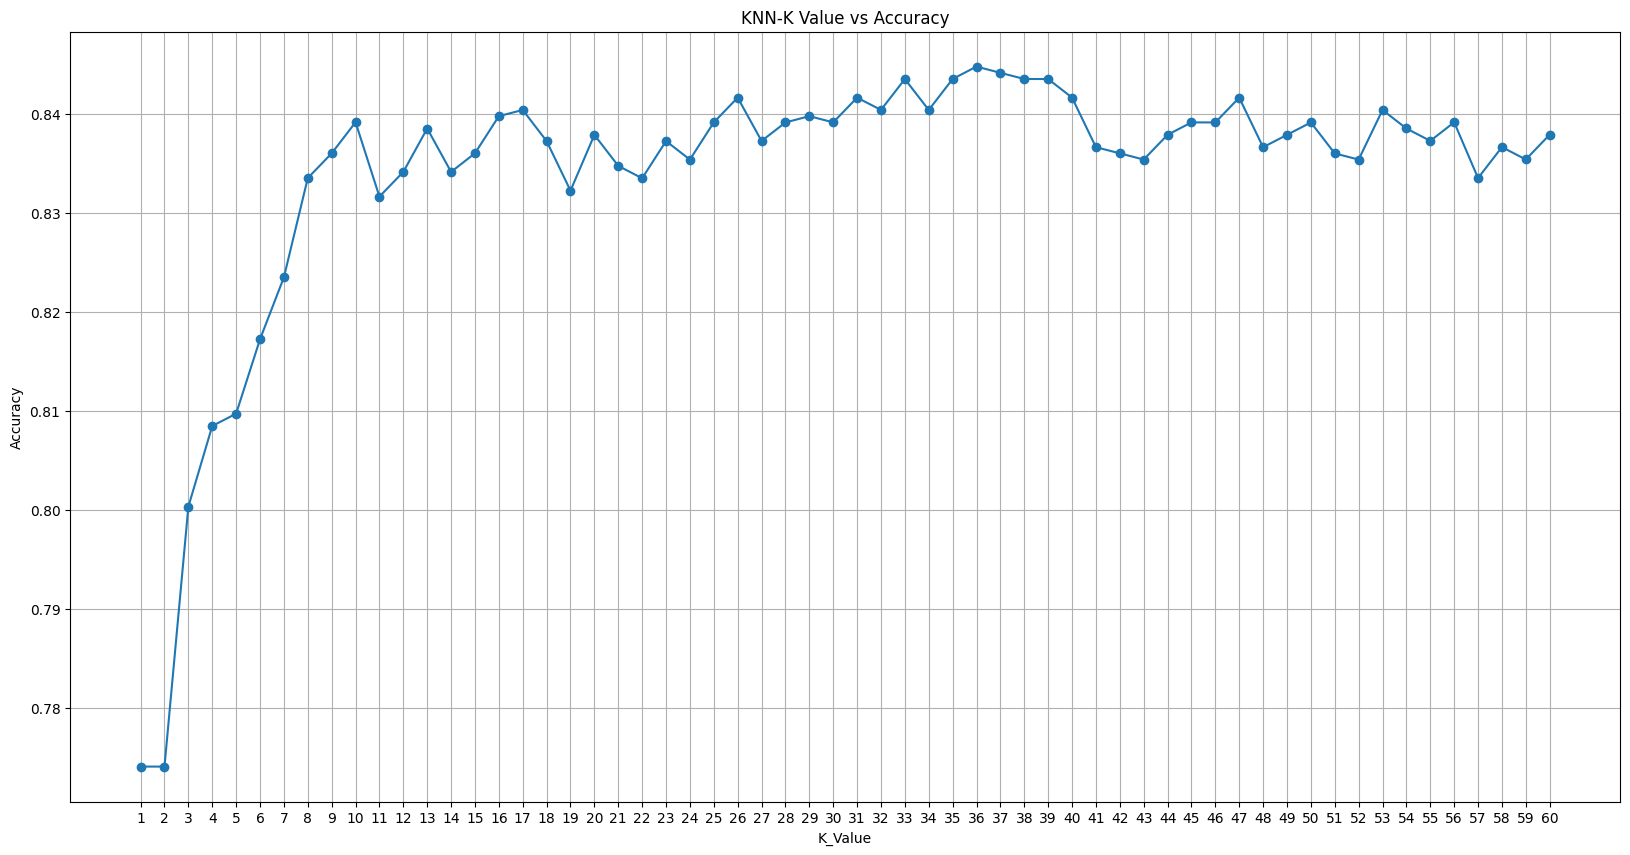

In [86]:
plt.figure(figsize=(20,10))
plt.plot(K_values,accuracies,marker ='o')
plt.xlabel('K_Value')
plt.ylabel('Accuracy')
plt.title('KNN-K Value vs Accuracy')
plt.xticks(range(1,61))
plt.grid(True)
plt.show()

### Build the final KNN model with k =11

In [92]:
# build final knn model with best k
knn_final = KNeighborsClassifier(n_neighbors=11)
knn_final.fit(X_train_scaled,y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
 
# evaluation
print("Accuracy :",accuracy_score(y_test,y_pred_knn))
print("\nClassification Report:\n",classification_report(y_test,y_pred))


Accuracy : 0.8375

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.79      0.83      0.81       100
           2       0.71      0.72      0.72       100
           3       0.90      0.83      0.86       100

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



### Confusion matrix

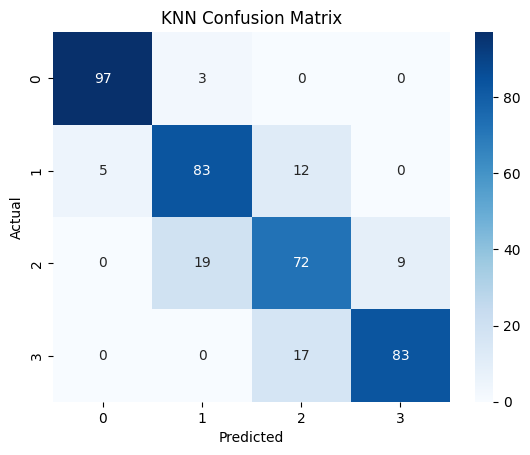

In [91]:
cm = confusion_matrix(y_test,y_pred)
plt.Figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel("Actual")
plt.title('KNN Confusion Matrix')
plt.show()


### Save the model

In [89]:
import joblib
joblib.dump(knn_final,'../models/knn_model.pkl')
print("KNN model saved!")

KNN model saved!
